# Aplicação de um SIN para controle de central de reparo de peças.

O problema é desenvolver e implementar um SIN para gerenciar uma central de reparo e distribuição de peças, de forma a reduzir o tempo de espera pelo serviço.


In [16]:
%%html
<style>
  table > caption,
  table > tbody > tr > th {
    font-weight: bold;
  }
</style>


In [17]:
import numpy as np
import skfuzzy as fuzzy
from babel.numbers import format_decimal as decimal
from IPython.display import HTML, display
from skfuzzy import control as ctrl
from skfuzzy.cluster import cmeans

## Modelagem do problema

A modelagem nebulosa do problema real compreende:

1.  definir o contexto e a questão a ser tratada. I.e., definir o problema que se quer resolver, a pergunta que se quer responder ou a decisão a ser tomada. Ainda, definir qual o contexto da questão, ou seja, definir os atores e sob quais circunstâncias, aspectos e negócio a questão está sendo percebida;

2.  definir qual a variável linguística de saída que será o resultado, resposta ou decisão da questão a ser tratada;

3.  definir os termos linguísticos (conjuntos nebulosos) da variável de saída. I.e., os possíveis valores que a variável de saída pode assumir;

4.  definir a representação dos conjuntos nebulosos da variável de saída. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

5.  definir as variáveis linguísticas de entrada;

6.  definir os termos linguísticos (conjuntos nebulosos) de cada variável de entrada. I.e., os possíveis valores que as variáveis de entrada podem assumir;

7.  definir a representação dos conjuntos nebulosos das variáveis de entrada. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

8.  definir as regras de inferência;

9.  definir o método de inferência que, na maioria das vezes, poderá ser Mandani ou Larsen. Mas, podem ser usado outros métodos, dependendo do problema em questão;

10. definir o método de defuzzificação.


## Definição do problema


### Contexto

- **Objetivo:** Aplicação de um SIN para estabelecer um estoque adequado para reduzir o tempo de atendimento em uma central de peças.
- **Pergunta:** Qual é o estoque de peças em perfeito estado necessário?
- **Atores:** Cliente que leva a peça para ser reparada e que deseja uma peça reparada, gerente da loja que gerencia a alocação de recursos.
- **Circunstâncias:** O usuário chega à loja com uma peça com defeito, e solicita que ela seja trocada por uma peça nova. O cliente deve receber uma peça em perfeito estado do estoque. Aquela com defeito deve ser reparada e colocada no estoque.
- **Aspectos:** Deve-se analisar o estoque ideal para diferentes exigências de celeridade no atendimento.


### Saída

#### Estoque (`N`)

Quantidade de peças em **estoque** necessária para entregar ao cliente.

- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Muito pequeno (`MP`): [0, 4] &mdash; [0.0, 0.2].
- Pequeno (`P`): ]4, 6] &mdash; ]0.2, 0.3].
- Razoavelmente pequeno (`RP`): ]6, 8] &mdash; ]0.3, 0.4].
- Médio (`M`): ]8, 12] &mdash; ]0.4, 0.6].
- Razoavelmente grande (`RG`): ]12, 14] &mdash; ]0.6, 0.7].
- Grande (`G`): ]14, 16] &mdash; ]0.7, 0.8].
- Muito grande (`MG`): ]16, 20] &mdash; ]0.8, 1.0].

Representação:

- Funções de pertinência:
  - trapezoidais para os termos `MP` e `MG`;
  - triangulares para demais termos.


/home/gabriel/dev/fuzzy_systems/a2s2/.venv/lib64/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


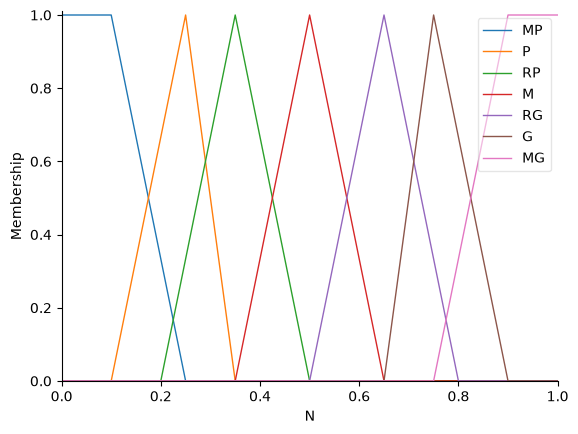

In [18]:
# Define o universo de valores.
stock_universe = np.arange(0, 1.05, 0.05)

# Define a variável.
stock_variable = ctrl.Consequent(stock_universe, "N")

# Define as funções de pertinência.
stock_variable["MP"] = fuzzy.trapmf(stock_variable.universe, [0.0, 0.0, 0.1, 0.25])
stock_variable["P"] = fuzzy.trimf(stock_variable.universe, [0.1, 0.25, 0.35])
stock_variable["RP"] = fuzzy.trimf(stock_variable.universe, [0.2, 0.35, 0.5])
stock_variable["M"] = fuzzy.trimf(stock_variable.universe, [0.35, 0.5, 0.65])
stock_variable["RG"] = fuzzy.trimf(stock_variable.universe, [0.5, 0.65, 0.8])
stock_variable["G"] = fuzzy.trimf(stock_variable.universe, [0.65, 0.75, 0.9])
stock_variable["MG"] = fuzzy.trapmf(stock_variable.universe, [0.75, 0.9, 1.0, 1.0])

stock_variable.view()

# Checagem de cobertura.
stock_coverage = np.maximum.reduce(
    [
        stock_variable["MP"].mf,
        stock_variable["P"].mf,
        stock_variable["RP"].mf,
        stock_variable["M"].mf,
        stock_variable["RG"].mf,
        stock_variable["G"].mf,
        stock_variable["MG"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {stock_universe[stock_coverage == 0]}"))


### Entrada


#### Tempo de espera (`M`)

Tempo de **espera** médio do cliente para receber uma peça nova.

- Dado entre 0 e 20 minutos.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Muito pequeno (`MP`): [0.0, 0.2].
- Pequeno (`P`): ]0.2, 0.4].
- Médio (`M`): ]0.4, 0.6].

Representação:

- Funções de pertinência:
  - trapezoidais para os termos `MP` e `M`;
  - triangular para o termo `P`.


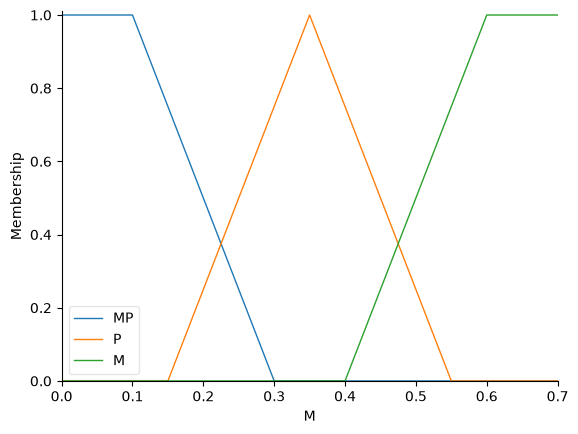

In [19]:
# Define o universo de valores.
wait_universe = np.arange(0, 0.75, 0.05)

# Define a variável.
wait_variable = ctrl.Antecedent(wait_universe, "M")

# Define as funções de pertinência.
wait_variable["MP"] = fuzzy.trapmf(wait_universe, [0.0, 0.0, 0.1, 0.3])
wait_variable["P"] = fuzzy.trimf(wait_universe, [0.15, 0.35, 0.55])
wait_variable["M"] = fuzzy.trapmf(wait_universe, [0.4, 0.6, 0.7, 0.75])

wait_variable.view()

# Checagem de cobertura.
wait_coverage = np.maximum.reduce(
    [
        wait_variable["MP"].mf,
        wait_variable["P"].mf,
        wait_variable["M"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {wait_universe[wait_coverage == 0]}"))


#### Quantidade de funcionários (`S`)

Quantidade de **funcionários** disponíveis.

- Dado entre 2 e 20.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Muito pequeno (`MP`): [2, 3] &mdash; [0.1, 0.15].
- Pequeno (`P`): ]3, 5] &mdash; ]0.15, 0.25].
- Razoavelmente pequeno (`RP`): ]5, 8] &mdash; ]0.25, 0.4].
- Médio (`M`): ]8, 12] &mdash; ]0.4, 0.6].
- Razoavelmente grande (`RG`): ]12, 14] &mdash; ]0.6, 0.7].
- Grande (`G`): ]14, 16] &mdash; ]0.7, 0.8].
- Muito grande (`MG`): ]16, 20] &mdash; ]0.8, 1.0].

Representação:

- Funções de pertinência:
  - linear para o termo `MP`;
  - trapezoidal para os termo `RP` e `MG`;
  - triangulares para demais termos.


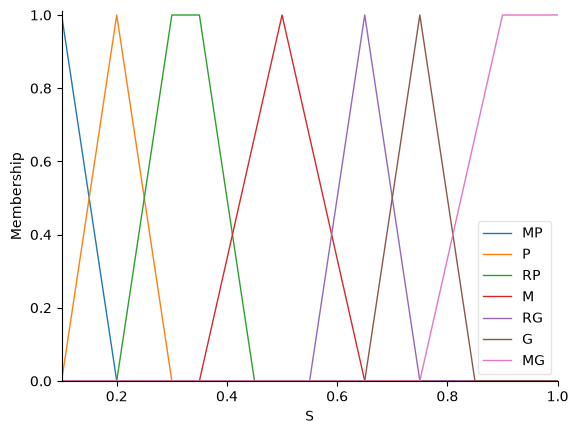

In [20]:
# Define o universo de valores.
employees_universe = np.arange(0.1, 1.05, 0.05)

# Define a variável.
employees_variable = ctrl.Antecedent(employees_universe, "S")

# Define as funções de pertinência.
employees_variable["MP"] = fuzzy.trimf(employees_variable.universe, [0.10, 0.10, 0.20])
employees_variable["P"] = fuzzy.trimf(employees_variable.universe, [0.10, 0.20, 0.30])
employees_variable["RP"] = fuzzy.trapmf(
    employees_variable.universe, [0.20, 0.30, 0.35, 0.45]
)
employees_variable["M"] = fuzzy.trimf(employees_variable.universe, [0.35, 0.5, 0.65])
employees_variable["RG"] = fuzzy.trimf(employees_variable.universe, [0.55, 0.65, 0.75])
employees_variable["G"] = fuzzy.trimf(employees_variable.universe, [0.65, 0.75, 0.85])

employees_variable["MG"] = fuzzy.trapmf(
    employees_variable.universe, [0.75, 0.9, 1.0, 1.05]
)

employees_variable.view()

# Checagem de cobertura.
employees_coverage = np.maximum.reduce(
    [
        employees_variable["MP"].mf,
        employees_variable["P"].mf,
        employees_variable["RP"].mf,
        employees_variable["M"].mf,
        employees_variable["RG"].mf,
        employees_variable["G"].mf,
        employees_variable["MG"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {employees_universe[employees_coverage == 0]}"))

#### Fator de uso (`P`)

Fator de **uso** da central de reparos.

- Dado em porcentagem.
- Normalizado entre 0.0 e 1.0.

Termos linguísticos:

- Baixo (`B`).
- Médio (`M`).
- Alto (`A`).
- Muito alto (`MA`).

Representação:

- Funções de pertinência:
  - distribuição de Poisson.


In [21]:
seed = np.random.seed(92)
quantity_of_samples = 100

# Taxa de chegada de peças — Número médio de clientes por unidade de tempo.
arrival_rate = 4

sample = np.random.poisson(lam=arrival_rate, size=quantity_of_samples)
normalized_sample = sample / sample.max()

display(sample)
display(normalized_sample)

array([4, 7, 7, 5, 2, 0, 5, 3, 4, 4, 4, 2, 8, 2, 5, 4, 8, 1, 3, 4, 2, 3,
       4, 4, 4, 5, 2, 1, 2, 3, 5, 1, 2, 3, 0, 6, 5, 2, 2, 5, 7, 2, 5, 5,
       4, 4, 3, 5, 3, 8, 4, 1, 6, 7, 3, 5, 5, 3, 4, 4, 5, 7, 3, 3, 3, 1,
       5, 4, 3, 3, 4, 7, 3, 7, 3, 7, 6, 4, 4, 8, 4, 3, 1, 2, 5, 3, 4, 3,
       5, 2, 4, 8, 4, 2, 6, 3, 7, 9, 4, 2])

array([0.44444444, 0.77777778, 0.77777778, 0.55555556, 0.22222222,
       0.        , 0.55555556, 0.33333333, 0.44444444, 0.44444444,
       0.44444444, 0.22222222, 0.88888889, 0.22222222, 0.55555556,
       0.44444444, 0.88888889, 0.11111111, 0.33333333, 0.44444444,
       0.22222222, 0.33333333, 0.44444444, 0.44444444, 0.44444444,
       0.55555556, 0.22222222, 0.11111111, 0.22222222, 0.33333333,
       0.55555556, 0.11111111, 0.22222222, 0.33333333, 0.        ,
       0.66666667, 0.55555556, 0.22222222, 0.22222222, 0.55555556,
       0.77777778, 0.22222222, 0.55555556, 0.55555556, 0.44444444,
       0.44444444, 0.33333333, 0.55555556, 0.33333333, 0.88888889,
       0.44444444, 0.11111111, 0.66666667, 0.77777778, 0.33333333,
       0.55555556, 0.55555556, 0.33333333, 0.44444444, 0.44444444,
       0.55555556, 0.77777778, 0.33333333, 0.33333333, 0.33333333,
       0.11111111, 0.55555556, 0.44444444, 0.33333333, 0.33333333,
       0.44444444, 0.77777778, 0.33333333, 0.77777778, 0.33333

In [22]:
# Aplicar Fuzzy C-Means (FCM) com 4 clusters, sendo cada cluster um conjunto.
centroids, msmatrix, _, _, _, _, _ = cmeans(
    data=normalized_sample.reshape(1, -1), c=4, m=2.0, error=0.005, maxiter=1000
)

sorted_centroids = np.sort(centroids.flatten())
display(sorted_centroids)

array([0.17972138, 0.37983535, 0.55583102, 0.82015804])

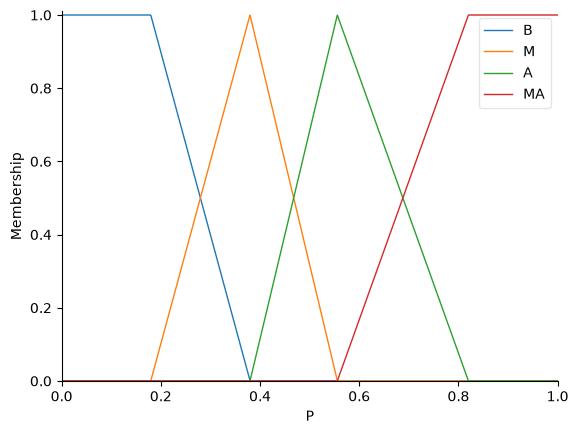

In [23]:
# Define o universo de valores.
usage_universe = np.arange(0, 1.001, 0.001)

# Define a variável.
usage_variable = ctrl.Antecedent(usage_universe, "P")

# Define as funções de pertinência.
usage_variable["B"] = fuzzy.trapmf(
    usage_universe, [0, 0, sorted_centroids[0], sorted_centroids[1]]
)
usage_variable["M"] = fuzzy.trimf(
    usage_universe, [sorted_centroids[0], sorted_centroids[1], sorted_centroids[2]]
)
usage_variable["A"] = fuzzy.trimf(
    usage_universe, [sorted_centroids[1], sorted_centroids[2], sorted_centroids[3]]
)
usage_variable["MA"] = fuzzy.trapmf(
    usage_universe, [sorted_centroids[2], sorted_centroids[3], 1, 1]
)

usage_variable.view()

# Checagem de cobertura.
usage_coverage = np.maximum.reduce(
    [
        usage_variable["B"].mf,
        usage_variable["M"].mf,
        usage_variable["A"].mf,
        usage_variable["MA"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {usage_universe[usage_coverage == 0]}"))

## Criação de regras de inferência


### Matrizes associativas fuzzy

#### Tempo de espera (`M`): Muito pequeno (`MP`)

**Quantidade de funcionários (`S`) / Fator de uso (`P`)**

|        |  MA |   A |   M |   B |
| :----: | --: | --: | --: | --: |
| **MP** |  MG |  MG |   G |  RG |
| **P**  |  MG |   G |  RG |   M |
| **RP** |   G |  RG |   M |  RP |
| **M**  |  RG |   M |  RP |   P |
| **RG** |   M |  RP |   P |  MP |
| **G**  |  RP |   P |  MP |  MP |
| **MG** |   P |  MP |  MP |  MP |

#### Tempo de espera (`M`): Pequeno (`P`)

**Quantidade de funcionários (`S`) / Fator de uso (`P`)**

|        |  MA |   A |   M |   B |
| ------ | --: | --: | --: | --: |
| **MP** |  MG |  MG |  MG |   G |
| **P**  |  MG |  MG |   G |  RG |
| **RP** |  MG |   G |  RG |   M |
| **M**  |   G |  RG |   M |  RP |
| **RG** |  RG |   M |  RP |   P |
| **G**  |   M |  RP |   P |  MP |
| **MG** |  RP |   P |  MP |  MP |

#### Tempo de espera (`M`): Médio (`M`)

**Quantidade de funcionários (`S`) / Fator de uso (`P`)**

|        |  MA |   A |   M |   B |
| ------ | --: | --: | --: | --: |
| **MP** |  MG |  MG |  MG |  MG |
| **P**  |  MG |  MG |  MG |   G |
| **RP** |  MG |  MG |   G |  RG |
| **M**  |  MG |   G |  RG |   M |
| **RG** |   G |  RG |   M |  RP |
| **G**  |  RG |   M |  RP |   P |
| **MG** |   M |  RP |   P |  MP |


### Definição das regras


In [24]:
# Tempo de espera: (M): Muito pequeno (MP)

r1 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MP"] & usage_variable["MA"],
    stock_variable["MG"],
)

r2 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MP"] & usage_variable["A"],
    stock_variable["MG"],
)

r3 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MP"] & usage_variable["M"],
    stock_variable["G"],
)

r4 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MP"] & usage_variable["B"],
    stock_variable["RG"],
)

r5 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["P"] & usage_variable["MA"],
    stock_variable["MG"],
)

r6 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["P"] & usage_variable["A"],
    stock_variable["G"],
)

r7 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["P"] & usage_variable["M"],
    stock_variable["RG"],
)

r8 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["P"] & usage_variable["B"],
    stock_variable["M"],
)

r9 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RP"] & usage_variable["MA"],
    stock_variable["G"],
)

r10 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RP"] & usage_variable["A"],
    stock_variable["RG"],
)

r11 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RP"] & usage_variable["M"],
    stock_variable["M"],
)

r12 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RP"] & usage_variable["B"],
    stock_variable["RP"],
)

r13 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["M"] & usage_variable["MA"],
    stock_variable["RG"],
)

r14 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["M"] & usage_variable["A"],
    stock_variable["M"],
)

r15 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["M"] & usage_variable["M"],
    stock_variable["RP"],
)

r16 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["M"] & usage_variable["B"],
    stock_variable["P"],
)

r17 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RG"] & usage_variable["MA"],
    stock_variable["M"],
)

r18 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RG"] & usage_variable["A"],
    stock_variable["RP"],
)

r19 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RG"] & usage_variable["M"],
    stock_variable["P"],
)

r20 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["RG"] & usage_variable["B"],
    stock_variable["MP"],
)

r21 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["G"] & usage_variable["MA"],
    stock_variable["RP"],
)

r22 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["G"] & usage_variable["A"],
    stock_variable["P"],
)

r23 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["G"] & usage_variable["M"],
    stock_variable["MP"],
)

r24 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["G"] & usage_variable["B"],
    stock_variable["MP"],
)

r25 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MG"] & usage_variable["MA"],
    stock_variable["P"],
)

r26 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MG"] & usage_variable["A"],
    stock_variable["MP"],
)

r27 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MG"] & usage_variable["M"],
    stock_variable["MP"],
)

r28 = ctrl.Rule(
    wait_variable["MP"] & employees_variable["MG"] & usage_variable["B"],
    stock_variable["MP"],
)


# Tempo de espera: (M): Pequeno (P)

r29 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MP"] & usage_variable["MA"],
    stock_variable["MG"],
)

r30 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MP"] & usage_variable["A"],
    stock_variable["MG"],
)

r31 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MP"] & usage_variable["M"],
    stock_variable["MG"],
)

r32 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MP"] & usage_variable["B"],
    stock_variable["G"],
)

r33 = ctrl.Rule(
    wait_variable["P"] & employees_variable["P"] & usage_variable["MA"],
    stock_variable["MG"],
)

r34 = ctrl.Rule(
    wait_variable["P"] & employees_variable["P"] & usage_variable["A"],
    stock_variable["MG"],
)

r35 = ctrl.Rule(
    wait_variable["P"] & employees_variable["P"] & usage_variable["M"],
    stock_variable["G"],
)

r36 = ctrl.Rule(
    wait_variable["P"] & employees_variable["P"] & usage_variable["B"],
    stock_variable["RG"],
)

r37 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RP"] & usage_variable["MA"],
    stock_variable["MG"],
)

r38 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RP"] & usage_variable["A"],
    stock_variable["G"],
)

r39 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RP"] & usage_variable["M"],
    stock_variable["RG"],
)

r40 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RP"] & usage_variable["B"],
    stock_variable["M"],
)

r41 = ctrl.Rule(
    wait_variable["P"] & employees_variable["M"] & usage_variable["MA"],
    stock_variable["G"],
)

r42 = ctrl.Rule(
    wait_variable["P"] & employees_variable["M"] & usage_variable["A"],
    stock_variable["RG"],
)

r43 = ctrl.Rule(
    wait_variable["P"] & employees_variable["M"] & usage_variable["M"],
    stock_variable["M"],
)

r44 = ctrl.Rule(
    wait_variable["P"] & employees_variable["M"] & usage_variable["B"],
    stock_variable["RP"],
)

r45 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RG"] & usage_variable["MA"],
    stock_variable["RG"],
)

r46 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RG"] & usage_variable["A"],
    stock_variable["M"],
)

r47 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RG"] & usage_variable["M"],
    stock_variable["RP"],
)

r48 = ctrl.Rule(
    wait_variable["P"] & employees_variable["RG"] & usage_variable["B"],
    stock_variable["P"],
)

r49 = ctrl.Rule(
    wait_variable["P"] & employees_variable["G"] & usage_variable["MA"],
    stock_variable["M"],
)

r50 = ctrl.Rule(
    wait_variable["P"] & employees_variable["G"] & usage_variable["A"],
    stock_variable["RP"],
)

r51 = ctrl.Rule(
    wait_variable["P"] & employees_variable["G"] & usage_variable["M"],
    stock_variable["P"],
)

r52 = ctrl.Rule(
    wait_variable["P"] & employees_variable["G"] & usage_variable["B"],
    stock_variable["MP"],
)

r53 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MG"] & usage_variable["MA"],
    stock_variable["RP"],
)

r54 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MG"] & usage_variable["A"],
    stock_variable["P"],
)

r55 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MG"] & usage_variable["M"],
    stock_variable["MP"],
)

r56 = ctrl.Rule(
    wait_variable["P"] & employees_variable["MG"] & usage_variable["B"],
    stock_variable["MP"],
)

# Tempo de espera: (M): Médio (M)

r57 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MP"] & usage_variable["MA"],
    stock_variable["MG"],
)

r58 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MP"] & usage_variable["A"],
    stock_variable["MG"],
)

r59 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MP"] & usage_variable["M"],
    stock_variable["MG"],
)

r60 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MP"] & usage_variable["B"],
    stock_variable["MG"],
)

r61 = ctrl.Rule(
    wait_variable["M"] & employees_variable["P"] & usage_variable["MA"],
    stock_variable["MG"],
)

r62 = ctrl.Rule(
    wait_variable["M"] & employees_variable["P"] & usage_variable["A"],
    stock_variable["MG"],
)

r63 = ctrl.Rule(
    wait_variable["M"] & employees_variable["P"] & usage_variable["M"],
    stock_variable["MG"],
)

r64 = ctrl.Rule(
    wait_variable["M"] & employees_variable["P"] & usage_variable["B"],
    stock_variable["G"],
)

r65 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RP"] & usage_variable["MA"],
    stock_variable["MG"],
)

r66 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RP"] & usage_variable["A"],
    stock_variable["MG"],
)

r67 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RP"] & usage_variable["M"],
    stock_variable["G"],
)

r68 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RP"] & usage_variable["B"],
    stock_variable["RG"],
)

r69 = ctrl.Rule(
    wait_variable["M"] & employees_variable["M"] & usage_variable["MA"],
    stock_variable["MG"],
)

r70 = ctrl.Rule(
    wait_variable["M"] & employees_variable["M"] & usage_variable["A"],
    stock_variable["G"],
)

r71 = ctrl.Rule(
    wait_variable["M"] & employees_variable["M"] & usage_variable["M"],
    stock_variable["RG"],
)

r72 = ctrl.Rule(
    wait_variable["M"] & employees_variable["M"] & usage_variable["B"],
    stock_variable["M"],
)

r73 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RG"] & usage_variable["MA"],
    stock_variable["G"],
)

r74 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RG"] & usage_variable["A"],
    stock_variable["RG"],
)

r75 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RG"] & usage_variable["M"],
    stock_variable["M"],
)

r76 = ctrl.Rule(
    wait_variable["M"] & employees_variable["RG"] & usage_variable["B"],
    stock_variable["RP"],
)

r77 = ctrl.Rule(
    wait_variable["M"] & employees_variable["G"] & usage_variable["MA"],
    stock_variable["RG"],
)

r78 = ctrl.Rule(
    wait_variable["M"] & employees_variable["G"] & usage_variable["A"],
    stock_variable["M"],
)

r79 = ctrl.Rule(
    wait_variable["M"] & employees_variable["G"] & usage_variable["M"],
    stock_variable["RP"],
)

r80 = ctrl.Rule(
    wait_variable["M"] & employees_variable["G"] & usage_variable["B"],
    stock_variable["P"],
)

r81 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MG"] & usage_variable["MA"],
    stock_variable["M"],
)

r82 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MG"] & usage_variable["A"],
    stock_variable["RP"],
)

r83 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MG"] & usage_variable["M"],
    stock_variable["P"],
)

r84 = ctrl.Rule(
    wait_variable["M"] & employees_variable["MG"] & usage_variable["B"],
    stock_variable["MP"],
)

# Compilação

rules = [
    r1,
    r2,
    r3,
    r4,
    r5,
    r6,
    r7,
    r8,
    r9,
    r10,
    r11,
    r12,
    r13,
    r14,
    r15,
    r16,
    r17,
    r18,
    r19,
    r20,
    r21,
    r22,
    r23,
    r24,
    r25,
    r26,
    r27,
    r28,
    r29,
    r30,
    r31,
    r32,
    r33,
    r34,
    r35,
    r36,
    r37,
    r38,
    r39,
    r40,
    r41,
    r42,
    r43,
    r44,
    r45,
    r46,
    r47,
    r48,
    r49,
    r50,
    r51,
    r52,
    r53,
    r54,
    r55,
    r56,
    r57,
    r58,
    r59,
    r60,
    r61,
    r62,
    r63,
    r64,
    r65,
    r66,
    r67,
    r68,
    r69,
    r70,
    r71,
    r72,
    r73,
    r74,
    r75,
    r76,
    r77,
    r78,
    r79,
    r80,
    r81,
    r82,
    r83,
    r84,
]


## Simulação

### Controle


In [25]:
### Método de controle


def get_simulation_control(defuzzify_method="centroid"):
    stock_variable.defuzzify_method = defuzzify_method
    stock_ctrl = ctrl.ControlSystem(rules)
    stock_simulation = ctrl.ControlSystemSimulation(stock_ctrl)
    return stock_simulation


def predict_stock(
    wait: float, employees: float, usage: float, defuzzify_method="centroid"
):
    stock_simulation = get_simulation_control(defuzzify_method=defuzzify_method)
    stock_simulation.input["M"] = wait
    stock_simulation.input["S"] = employees
    stock_simulation.input["P"] = usage
    stock_simulation.compute()
    return stock_simulation.output["N"], stock_simulation


def simulate_and_display(
    wait: float,
    employees: float,
    usage: float,
    plot_input: bool = False,
    plot_output=False,
    defuzzify_method="centroid",
):
    prediction, stock_simulation = predict_stock(
        wait=wait,
        employees=employees,
        usage=usage,
        defuzzify_method=defuzzify_method,
    )
    display(
        HTML(
            f"""<table><caption>Cálculo do tamanho do estoque.</caption>
                    <thead>
                        <tr>
                            <th>Tempo de espera</th>
                            <th>Quantidade de funcionários</th>
                            <th>Fator de uso</th>
                            <th>Estoque</th>
                            <th>N. peças</th>
                        </tr>
                    </thead>
                    <tbody>
                        <tr>
                            <td>{decimal(wait, locale="pt_BR")}</td>
                            <td>{decimal(employees, locale="pt_BR")}</td>
                            <td>{decimal(usage, locale="pt_BR")}</td>
                            <td>{decimal(prediction, locale="pt_BR")}</td>
                            <td>{(prediction * 20):.0f}</td>
                    </tbody>
                </table>"""
        )
    )
    if plot_input:
        wait_variable.view(sim=stock_simulation)
        employees_variable.view(sim=stock_simulation)
        usage_variable.view(sim=stock_simulation)
    if plot_output:
        stock_variable.view(sim=stock_simulation)


def simulate_and_display_many(data, defuzzify_method="centroid"):
    rows = []

    for wait, employees, usage in data:
        prediction, _ = predict_stock(
            wait=wait,
            employees=employees,
            usage=usage,
            defuzzify_method=defuzzify_method,
        )

        rows.append(
            f"""
            <tr>
                <td>{decimal(wait, locale="pt_BR")}</td>
                <td>{decimal(employees, locale="pt_BR")}</td>
                <td>{decimal(usage, locale="pt_BR")}</td>
                <td>{decimal(prediction, locale="pt_BR")}</td>
                <td>{(prediction * 20):.0f}</td>
            </tr>
            """
        )

    display(
        HTML(
            f"""
            <table>
                <caption>Cálculo da duração do ciclo de lavagem.</caption>
                <thead>
                    <tr>
                        <th>Tempo de espera</th>
                        <th>Quantidade de funcionários</th>
                        <th>Fator de uso</th>
                        <th>Estoque</th>
                        <th>N. peças</th>
                    </tr>
                </thead>
                <tbody>
                    {"".join(rows)}
                </tbody>
            </table>
            """
        )
    )

In [26]:
display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display(wait=0.15, employees=0.2, usage=0.9, defuzzify_method="centroid")

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display(wait=0.15, employees=0.2, usage=0.9, defuzzify_method="mom")


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,9",18


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,928",19


### Método de inferência

Foi decidido utilizar o método de Mamdani, que é o padrão da biblioteca.


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,9",18


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,928",19


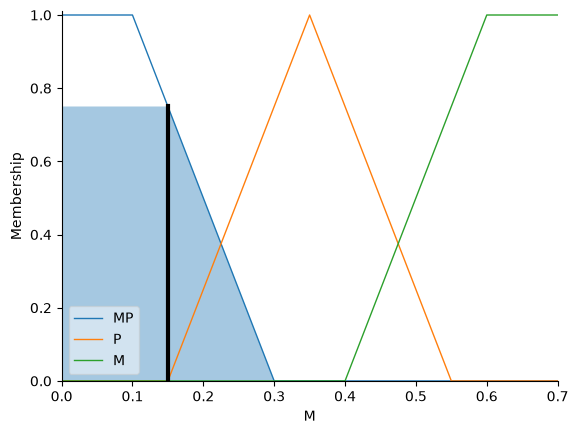

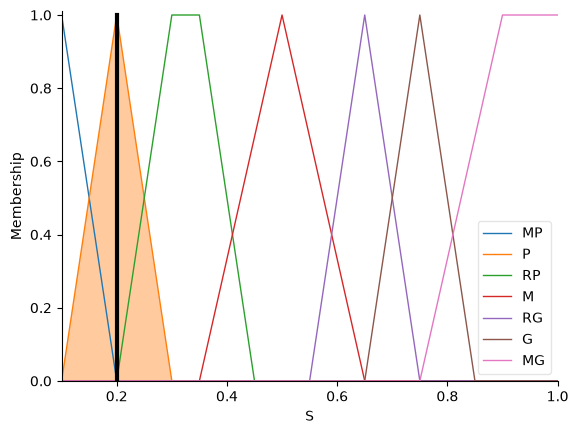

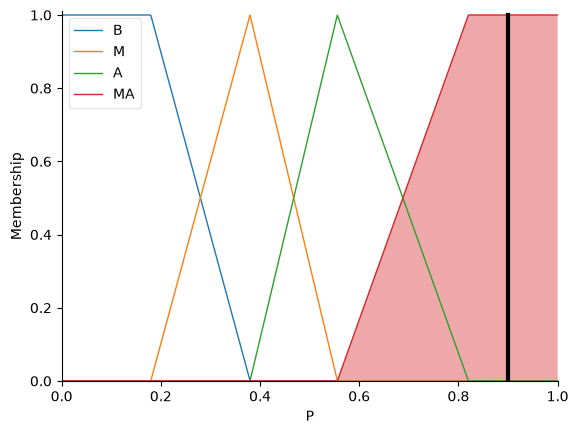

In [27]:
display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display(
    wait=0.15, employees=0.2, usage=0.9, plot_input=True, defuzzify_method="centroid"
)

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display(wait=0.15, employees=0.2, usage=0.9, defuzzify_method="mom")


### Defuzzificação

Foi decidido utilizar os métodos de Centroide e de Média dos máximos.


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,9",18


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,928",19


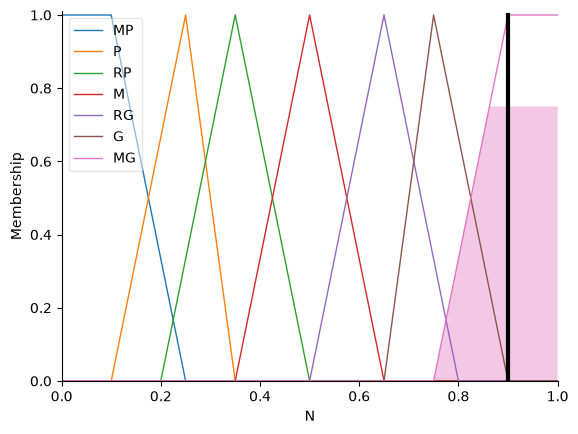

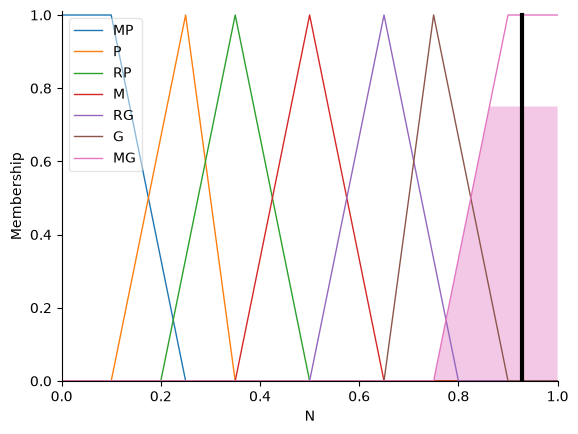

In [28]:
display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display(
    wait=0.15, employees=0.2, usage=0.9, defuzzify_method="centroid", plot_output=True
)

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display(
    wait=0.15, employees=0.2, usage=0.9, defuzzify_method="mom", plot_output=True
)


## Exemplos


In [29]:
data = [
    (0.15, 0.2, 0.9),
    (0.2, 0.9, 0.8),
    (0.3, 0.5, 0.7),
    (0.7, 0.7, 0.6),
    (0.6, 0.4, 0.5),
    (0.45, 0.3, 0.4),
    (0.1, 0.2, 0.3),
    (0.2, 0.8, 0.2),
    (0.3, 0.5, 0.1),
]

display(HTML("<strong>Método de defuzzificação: centroide</strong>"))
simulate_and_display_many(
    defuzzify_method="centroid",
    data=data,
)

display(HTML("<strong>Método de defuzzificação: média dos máximos</strong>"))
simulate_and_display_many(
    defuzzify_method="mom",
    data=data,
)


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,9",18
"0,2","0,9","0,8","0,267",5
"0,3","0,5","0,7","0,704",14
"0,7","0,7","0,6","0,598",12
"0,6","0,4","0,5","0,788",16
"0,45","0,3","0,4","0,706",14
"0,1","0,2","0,3","0,587",12
"0,2","0,8","0,2","0,125",3
"0,3","0,5","0,1","0,35",7


Tempo de espera,Quantidade de funcionários,Fator de uso,Estoque,N. peças
"0,15","0,2","0,9","0,928",19
"0,2","0,9","0,8","0,234",5
"0,3","0,5","0,7","0,761",15
"0,7","0,7","0,6","0,654",13
"0,6","0,4","0,5","0,91",18
"0,45","0,3","0,4","0,656",13
"0,1","0,2","0,3","0,635",13
"0,2","0,8","0,2","0,083",2
"0,3","0,5","0,1","0,35",7
